In [1]:
import numpy as np
import pandas as pd
import math

# 定义列名，跳过前13行头文件信息
fp_cols = ['Force X', 'Force Y', 'Force Z', 'Moment X', 'Moment Y', 'Moment Z', 'COP X', 'COP Y', 'Torque Z']
emg_cols = ['L.Glut.Max.', 'R.Glut.Max.', 'L.Rectus Fem.', 'R.Biceps Fem.', 'L.Lat. Gastro', 'R.Lat. Gastro']

# 1. 导入测力台数据 (1000Hz)
df2 = pd.read_csv('TEST0007_a_2.tsv', sep='\t', skiprows=13, usecols=[0,1,2,3,4,5,6,7,8], names=fp_cols, on_bad_lines='skip')
df3 = pd.read_csv('TEST0007_a_3.tsv', sep='\t', skiprows=13, usecols=[0,1,2,3,4,5,6,7,8], names=fp_cols, on_bad_lines='skip')
df4 = pd.read_csv('TEST0007_a_4.tsv', sep='\t', skiprows=13, usecols=[0,1,2,3,4,5,6,7,8], names=fp_cols, on_bad_lines='skip')
df5 = pd.read_csv('TEST0007_a_5.tsv', sep='\t', skiprows=13, usecols=[0,1,2,3,4,5,6,7,8], names=fp_cols, on_bad_lines='skip')

# 计算垂直方向总力 (vGRF)
total_vGRF = df2['Force Z'] + df3['Force Z'] + df4['Force Z'] + df5['Force Z']

# 2. 定位静息体重基线 (选取2000-2200帧的平稳期)
bw_mean = total_vGRF[2000:2200].mean()
bw_std = total_vGRF[2000:2200].std()
threshold = bw_mean - 5 * bw_std

# 3. 确定动作起点 (打破静息阈值)
onset_idx = None
for i in range(2200, len(total_vGRF)):
    if total_vGRF[i] < threshold:
        onset_idx = i
        break

# 4. 确定离地瞬间 (vGRF低于10N)
takeoff_idx = None
for i in range(onset_idx, len(total_vGRF)):
    if total_vGRF[i] < 10:
        takeoff_idx = i
        break

# 5. 基于冲量-动量定理计算高度
net_force = total_vGRF[onset_idx:takeoff_idx] - bw_mean
impulse = (net_force / 1000.0).sum()  # 1000Hz下dt=0.001s
mass = bw_mean / 9.81
takeoff_vel = impulse / mass
jump_height = (takeoff_vel ** 2) / (2 * 9.81)

print(f"体重(Body Weight): {bw_mean:.2f} N")
print(f"力学起点(Onset Index): {onset_idx}")
print(f"离地瞬间(Takeoff Index): {takeoff_idx}")
print(f"净冲量(Net Impulse): {impulse:.2f} Ns")
print(f"起跳速度(Takeoff Velocity): {takeoff_vel:.2f} m/s")
print(f"跳跃高度(Jump Height): {jump_height:.4f} m ({jump_height*100:.2f} cm)")

# 6. 导入肌电数据 (2000Hz)
df1 = pd.read_csv('TEST0007_a_1.tsv', sep='\t', skiprows=13, usecols=[0,1,2,3,4,5], names=emg_cols, on_bad_lines='skip')

# 7. 根据两倍频率映射肌电提取窗口
emg_onset = onset_idx * 2
emg_takeoff = takeoff_idx * 2
emg_window = df1.iloc[emg_onset:emg_takeoff]

# 计算均方根 (RMS)
rms_vals = np.sqrt((emg_window**2).mean())
print("\n=== 起跳推进阶段的EMG RMS ===")
print(rms_vals)

# 8. 计算对称角 (Symmetry Angle) -> 以臀大肌为例
# SA = (45° - arctan(Left / Right)) / 90° * 100% (越接近0越对称)
sa_glut = (45 - math.degrees(math.atan(rms_vals['L.Glut.Max.'] / rms_vals['R.Glut.Max.']))) / 90 * 100
print(f"\n臀大肌对称角 (SA): {sa_glut:.2f}%")

体重(Body Weight): 790.40 N
力学起点(Onset Index): 2358
离地瞬间(Takeoff Index): 2497
净冲量(Net Impulse): 32.41 Ns
起跳速度(Takeoff Velocity): 0.40 m/s
跳跃高度(Jump Height): 0.0082 m (0.82 cm)

=== 起跳推进阶段的EMG RMS ===
L.Glut.Max.      261.007514
R.Glut.Max.      372.330466
L.Rectus Fem.    121.742621
R.Biceps Fem.     22.863932
L.Lat. Gastro    155.346747
R.Lat. Gastro    132.174893
dtype: float64

臀大肌对称角 (SA): 11.08%


In [2]:
import numpy as np
import pandas as pd
import math

# 1. 导入指定主测力台的局部坐标系原始力学数据 (1000Hz)
# 跳过前27行文件头，由于没有标准列名，直接读取并通过iloc提取第3列(索引2)的垂直方向力(Z轴)
try:
    df_f1 = pd.read_csv('TEST0007_f_1.tsv', sep='\t', skiprows=27, header=None, on_bad_lines='skip')
    df_f2 = pd.read_csv('TEST0007_f_2.tsv', sep='\t', skiprows=27, header=None, on_bad_lines='skip')
    
    # 提取Z轴力并合并计算总垂直地面反作用力 (vGRF)，剔除末尾无效的NaN值
    fz_total = df_f1.iloc[:, 2].astype(float) + df_f2.iloc[:, 2].astype(float)
    fz_total = fz_total.dropna().reset_index(drop=True)
except Exception as e:
    print(f"读取测力台数据失败，请检查文件: {e}")
    exit()

# 2. 定位静息体重基线 (选取2000-2200帧的平稳期计算系统绝对体重)
bw_mean = fz_total[2000:2200].mean()
bw_std = fz_total[2000:2200].std()
threshold = bw_mean - 5 * bw_std

# 3. 确定动作起点 (首次向下打破体重5倍标准差阈值的瞬间)
onset_idx = None
for i in range(2200, len(fz_total)):
    if fz_total[i] < threshold:
        onset_idx = i
        break

# 4. 确定离地瞬间 (vGRF首次降至10N以下的瞬间)
takeoff_idx = None
if onset_idx is not None:
    for i in range(onset_idx, len(fz_total)):
        if fz_total[i] < 10:
            takeoff_idx = i
            break

# 5. 基于冲量-动量定理计算积分与跳跃高度
if onset_idx is not None and takeoff_idx is not None:
    net_force = fz_total[onset_idx:takeoff_idx] - bw_mean
    impulse = (net_force / 1000.0).sum()  # 1000Hz采样率下dt为0.001s
    mass = bw_mean / 9.81
    takeoff_vel = impulse / mass
    jump_height = (takeoff_vel ** 2) / (2 * 9.81)
    
    print("=== 动力学参数 (Impulse-Momentum) ===")
    print(f"校准静息体重(BW): {bw_mean:.2f} N")
    print(f"动作起点(Onset Frame): {onset_idx}")
    print(f"离地瞬间(Takeoff Frame): {takeoff_idx}")
    print(f"推进期净冲量(Net Impulse): {impulse:.2f} Ns")
    print(f"离地绝对速度(Takeoff Velocity): {takeoff_vel:.2f} m/s")
    print(f"积分推算高度(Jump Height): {jump_height:.4f} m")
else:
    print("未能成功识别完整的起跳与离地阶段，请检查截取的数据区间。")

# 6. 导入目标肌肉的肌电数据 (2000Hz)
# 根据要求仅提取a_1文件中间两列(索引2和3，对应原标签中的L.Rectus Fem.与R.Biceps Fem.位置，强制重命名为左右侧股直肌)
emg_cols = ['L.Rectus_Fem', 'R.Rectus_Fem']
try:
    df_emg = pd.read_csv('TEST0007_a_1.tsv', sep='\t', skiprows=13, usecols=[2, 3], names=emg_cols, on_bad_lines='skip')
except Exception as e:
    print(f"读取肌电数据失败，请检查文件: {e}")
    exit()

# 7. 根据两倍采样倍率(1000Hz->2000Hz)精准映射并截取肌电推进期窗口
if onset_idx is not None and takeoff_idx is not None:
    emg_onset = onset_idx * 2
    emg_takeoff = takeoff_idx * 2
    emg_window = df_emg.iloc[emg_onset:emg_takeoff]
    
    # 计算有效推进窗口内的均方根振幅 (RMS)
    rms_vals = np.sqrt((emg_window**2).mean())
    print("\n=== 起跳推进阶段的EMG RMS ===")
    print(f"左侧股直肌 (Left): {rms_vals['L.Rectus_Fem']:.2f}")
    print(f"右侧股直肌 (Right): {rms_vals['R.Rectus_Fem']:.2f}")
    
    # 8. 计算对称角 (Symmetry Angle) 进行左右侧肢体发力差异评估
    # SA公式 = (45° - arctan(Left/Right)) / 90° * 100%
    if rms_vals['R.Rectus_Fem'] != 0:
        ratio = rms_vals['L.Rectus_Fem'] / rms_vals['R.Rectus_Fem']
        sa = (45 - math.degrees(math.atan(ratio))) / 90 * 100
        print(f"\n目标肌群发力对称角 (SA): {sa:.2f}% (完美对称为0%，负值代表右侧极度劣势/左侧过度主导)")

=== 动力学参数 (Impulse-Momentum) ===
校准静息体重(BW): 790.31 N
动作起点(Onset Frame): 2358
离地瞬间(Takeoff Frame): 2497
推进期净冲量(Net Impulse): 32.41 Ns
离地绝对速度(Takeoff Velocity): 0.40 m/s
积分推算高度(Jump Height): 0.0083 m

=== 起跳推进阶段的EMG RMS ===
左侧股直肌 (Left): 121.74
右侧股直肌 (Right): 22.86

目标肌群发力对称角 (SA): -38.18% (完美对称为0%，负值代表右侧极度劣势/左侧过度主导)


In [5]:
import numpy as np
import pandas as pd
import math

try:
    # 强制读取文件，跳过前27行表头，并安全地将目标列转换为数值型
    df_f1 = pd.read_csv('TEST0008_f_1.tsv', sep='\t', skiprows=27, header=None, on_bad_lines='skip')
    df_f2 = pd.read_csv('TEST0008_f_2.tsv', sep='\t', skiprows=27, header=None, on_bad_lines='skip')
    
    # 提取第3列(索引2)的Z轴力，将无法识别的乱码转为NaN后填充为0，最后转换为numpy数组以便高速计算
    fz1 = pd.to_numeric(df_f1.iloc[:, 2], errors='coerce').fillna(0).values
    fz2 = pd.to_numeric(df_f2.iloc[:, 2], errors='coerce').fillna(0).values
    fz_total = fz1 + fz2
except Exception as e:
    print(f"测力台数据读取彻底失败，请确认文件路径与内部格式: {e}")
    exit()

# 使用滑动窗口算法(200ms)动态寻找静息站立期(方差最小且力值大于500N的阶段)
window_size = 200
min_std = float('inf')
bw_mean = 0
stable_idx = 0

for i in range(0, len(fz_total) - window_size, 50):
    window = fz_total[i:i+window_size]
    if np.mean(window) > 500 and np.std(window) < min_std:
        min_std = np.std(window)
        bw_mean = np.mean(window)
        stable_idx = i

if bw_mean == 0:
    print("未能在此数据中扫描到受试者稳定站立的阶段（承重<500N），数据片段无效。")
    exit()

threshold = bw_mean - 5 * min_std
onset_idx = None
takeoff_idx = None

# 从稳定站立期之后开始寻找起跳点(打破体重阈值)
for i in range(stable_idx + window_size, len(fz_total)):
    if fz_total[i] < threshold:
        onset_idx = i
        break

# 寻找离地瞬间(垂直力低于10N)
if onset_idx is not None:
    for i in range(onset_idx, len(fz_total)):
        if fz_total[i] < 10:
            takeoff_idx = i
            break

if onset_idx is not None and takeoff_idx is not None:
    net_force = fz_total[onset_idx:takeoff_idx] - bw_mean
    impulse = np.sum(net_force / 1000.0)
    mass = bw_mean / 9.81
    takeoff_vel = impulse / mass
    jump_height = (takeoff_vel ** 2) / (2 * 9.81)
    
    print("=== 自适应动力学分析 (Impulse-Momentum) ===")
    print(f"动态提取体重(BW): {bw_mean:.2f} N (截取始于第 {stable_idx} 帧)")
    print(f"动作起点(Onset): {onset_idx} 帧, 离地瞬间(Takeoff): {takeoff_idx} 帧")
    print(f"推进期净冲量: {impulse:.2f} Ns, 离地速度: {takeoff_vel:.2f} m/s")
    print(f"推算纵跳高度: {jump_height:.4f} m ({jump_height*100:.2f} cm)")
    
    try:
        # 同步截取肌电并计算
        df_emg = pd.read_csv('TEST0008_a_1.tsv', sep='\t', skiprows=13, usecols=[2, 3], names=['L.Rectus', 'R.Rectus'], on_bad_lines='skip')
        emg_window = df_emg.iloc[onset_idx*2 : takeoff_idx*2]
        
        rms_l = np.sqrt(np.mean(emg_window['L.Rectus']**2))
        rms_r = np.sqrt(np.mean(emg_window['R.Rectus']**2))
        
        print("\n=== 同步肌电不对称分析 (2000Hz) ===")
        print(f"左侧股直肌RMS: {rms_l:.2f}, 右侧股直肌RMS: {rms_r:.2f}")
        
        if rms_r != 0:
            sa = (45 - math.degrees(math.atan(rms_l / rms_r))) / 90 * 100
            print(f"发力对称角(SA): {sa:.2f}%")
        else:
            print("右侧肌电信号丢失，无法计算不对称度。")
    except Exception as e:
        print(f"\n肌电解析异常，请检查a_1文件格式或通道数: {e}")
else:
    print("未检测到有效发力或受试者完全腾空（力值未低于10N），该试次无效，请直接抛弃该组数据。")

=== 自适应动力学分析 (Impulse-Momentum) ===
动态提取体重(BW): 797.57 N (截取始于第 600 帧)
动作起点(Onset): 1177 帧, 离地瞬间(Takeoff): 1318 帧
推进期净冲量: 32.66 Ns, 离地速度: 0.40 m/s
推算纵跳高度: 0.0082 m (0.82 cm)

=== 同步肌电不对称分析 (2000Hz) ===
左侧股直肌RMS: 12.81, 右侧股直肌RMS: 46.85
发力对称角(SA): 33.01%


In [6]:
import numpy as np
import pandas as pd
import math

try:
    # 强制读取文件，跳过前27行表头，并安全地将目标列转换为数值型
    df_f1 = pd.read_csv('TEST0009_f_1.tsv', sep='\t', skiprows=27, header=None, on_bad_lines='skip')
    df_f2 = pd.read_csv('TEST0009_f_2.tsv', sep='\t', skiprows=27, header=None, on_bad_lines='skip')
    
    # 提取第3列(索引2)的Z轴力，将无法识别的乱码转为NaN后填充为0，最后转换为numpy数组以便高速计算
    fz1 = pd.to_numeric(df_f1.iloc[:, 2], errors='coerce').fillna(0).values
    fz2 = pd.to_numeric(df_f2.iloc[:, 2], errors='coerce').fillna(0).values
    fz_total = fz1 + fz2
except Exception as e:
    print(f"测力台数据读取彻底失败，请确认文件路径与内部格式: {e}")
    exit()

# 使用滑动窗口算法(200ms)动态寻找静息站立期(方差最小且力值大于500N的阶段)
window_size = 200
min_std = float('inf')
bw_mean = 0
stable_idx = 0

for i in range(0, len(fz_total) - window_size, 50):
    window = fz_total[i:i+window_size]
    if np.mean(window) > 500 and np.std(window) < min_std:
        min_std = np.std(window)
        bw_mean = np.mean(window)
        stable_idx = i

if bw_mean == 0:
    print("未能在此数据中扫描到受试者稳定站立的阶段（承重<500N），数据片段无效。")
    exit()

threshold = bw_mean - 5 * min_std
onset_idx = None
takeoff_idx = None

# 从稳定站立期之后开始寻找起跳点(打破体重阈值)
for i in range(stable_idx + window_size, len(fz_total)):
    if fz_total[i] < threshold:
        onset_idx = i
        break

# 寻找离地瞬间(垂直力低于10N)
if onset_idx is not None:
    for i in range(onset_idx, len(fz_total)):
        if fz_total[i] < 10:
            takeoff_idx = i
            break

if onset_idx is not None and takeoff_idx is not None:
    net_force = fz_total[onset_idx:takeoff_idx] - bw_mean
    impulse = np.sum(net_force / 1000.0)
    mass = bw_mean / 9.81
    takeoff_vel = impulse / mass
    jump_height = (takeoff_vel ** 2) / (2 * 9.81)
    
    print("=== 自适应动力学分析 (Impulse-Momentum) ===")
    print(f"动态提取体重(BW): {bw_mean:.2f} N (截取始于第 {stable_idx} 帧)")
    print(f"动作起点(Onset): {onset_idx} 帧, 离地瞬间(Takeoff): {takeoff_idx} 帧")
    print(f"推进期净冲量: {impulse:.2f} Ns, 离地速度: {takeoff_vel:.2f} m/s")
    print(f"推算纵跳高度: {jump_height:.4f} m ({jump_height*100:.2f} cm)")
    
    try:
        # 同步截取肌电并计算
        df_emg = pd.read_csv('TEST0009_a_1.tsv', sep='\t', skiprows=13, usecols=[2, 3], names=['L.Rectus', 'R.Rectus'], on_bad_lines='skip')
        emg_window = df_emg.iloc[onset_idx*2 : takeoff_idx*2]
        
        rms_l = np.sqrt(np.mean(emg_window['L.Rectus']**2))
        rms_r = np.sqrt(np.mean(emg_window['R.Rectus']**2))
        
        print("\n=== 同步肌电不对称分析 (2000Hz) ===")
        print(f"左侧股直肌RMS: {rms_l:.2f}, 右侧股直肌RMS: {rms_r:.2f}")
        
        if rms_r != 0:
            sa = (45 - math.degrees(math.atan(rms_l / rms_r))) / 90 * 100
            print(f"发力对称角(SA): {sa:.2f}%")
        else:
            print("右侧肌电信号丢失，无法计算不对称度。")
    except Exception as e:
        print(f"\n肌电解析异常，请检查a_1文件格式或通道数: {e}")
else:
    print("未检测到有效发力或受试者完全腾空（力值未低于10N），该试次无效，请直接抛弃该组数据。")

=== 自适应动力学分析 (Impulse-Momentum) ===
动态提取体重(BW): 802.57 N (截取始于第 600 帧)
动作起点(Onset): 824 帧, 离地瞬间(Takeoff): 995 帧
推进期净冲量: 35.91 Ns, 离地速度: 0.44 m/s
推算纵跳高度: 0.0098 m (0.98 cm)

=== 同步肌电不对称分析 (2000Hz) ===
左侧股直肌RMS: 18.77, 右侧股直肌RMS: 26.31
发力对称角(SA): 10.54%


In [8]:
import numpy as np
import pandas as pd
import math

# 定义测试试次集合，排除无效的15号数据
trials_side_B = [10, 11, 12]  # 假设为左侧，请根据实际情况确认
trials_side_A = [13, 14, 16]  # 假设为右侧，请根据实际情况确认

def process_slcmj(trial_num, emg_col_idx):
    file_f1 = f'TEST00{trial_num}_f_1.tsv'
    file_f2 = f'TEST00{trial_num}_f_2.tsv'
    file_a1 = f'TEST00{trial_num}_a_1.tsv'
    
    try:
        # 读取原始动力学数据并合并垂直Z轴力
        df_f1 = pd.read_csv(file_f1, sep='\t', skiprows=27, header=None, on_bad_lines='skip')
        df_f2 = pd.read_csv(file_f2, sep='\t', skiprows=27, header=None, on_bad_lines='skip')
        fz = pd.to_numeric(df_f1.iloc[:, 2], errors='coerce').fillna(0).values + \
             pd.to_numeric(df_f2.iloc[:, 2], errors='coerce').fillna(0).values
    except Exception as e:
        print(f"试次 {trial_num} 测力台数据读取失败: {e}")
        return None

    # 滑动窗口(200ms)动态寻找单腿静息承重期
    window_size = 200
    min_std = float('inf')
    bw_mean = 0
    stable_idx = 0
    
    for i in range(0, len(fz) - window_size, 50):
        window = fz[i:i+window_size]
        if np.mean(window) > 200 and np.std(window) < min_std:
            min_std = np.std(window)
            bw_mean = np.mean(window)
            stable_idx = i
            
    if bw_mean == 0:
        print(f"试次 {trial_num} 未找到稳定单腿站立期。")
        return None

    # 单脚跳核心阈值：下降5%静息体重作为动作起点
    threshold_onset = bw_mean * 0.95
    onset_idx = None
    takeoff_idx = None

    for i in range(stable_idx + window_size, len(fz)):
        if fz[i] < threshold_onset:
            onset_idx = i
            break

    if onset_idx is not None:
        for i in range(onset_idx, len(fz)):
            if fz[i] < 10:
                takeoff_idx = i
                break

    if onset_idx is None or takeoff_idx is None:
        print(f"试次 {trial_num} 未识别到完整起跳或离地动作。")
        return None

    # 冲量-动量定理计算
    net_force = fz[onset_idx:takeoff_idx] - bw_mean
    impulse = np.sum(net_force / 1000.0)
    mass = bw_mean / 9.81
    takeoff_vel = impulse / mass
    jump_height = (takeoff_vel ** 2) / (2 * 9.81)

    # 提取对应发力侧的肌电均方根
    try:
        df_emg = pd.read_csv(file_a1, sep='\t', skiprows=13, usecols=[2, 3], names=['L.Rectus', 'R.Rectus'], on_bad_lines='skip')
        emg_window = df_emg.iloc[onset_idx*2 : takeoff_idx*2]
        # 根据传入的列索引提取对应腿的肌电 (0对应左侧L.Rectus，1对应右侧R.Rectus)
        target_emg = emg_window['L.Rectus'] if emg_col_idx == 0 else emg_window['R.Rectus']
        rms_val = np.sqrt(np.mean(target_emg**2))
    except Exception as e:
        print(f"试次 {trial_num} 肌电读取失败: {e}")
        rms_val = np.nan

    return {'Height': jump_height, 'Impulse': impulse, 'RMS': rms_val}

# 聚合统计并计算不对称性
results_A = []
results_B = []

print("正在处理侧A (试次 10, 11, 12) ...")
for t in trials_side_A:
    res = process_slcmj(t, 0) # 假设侧A对应左腿肌电索引0
    if res: results_A.append(res)

print("正在处理侧B (试次 13, 14, 16) ...")
for t in trials_side_B:
    res = process_slcmj(t, 1) # 假设侧B对应右腿肌电索引1
    if res: results_B.append(res)

# 计算各指标均值
if results_A and results_B:
    avg_A = pd.DataFrame(results_A).mean()
    avg_B = pd.DataFrame(results_B).mean()
    
    print("\n=== 单脚反向跳(SLCMJ) 核心指标均值 ===")
    print(f"侧A - 跳跃高度: {avg_A['Height']:.4f}m, 冲量: {avg_A['Impulse']:.2f}Ns, 目标肌群RMS: {avg_A['RMS']:.2f}")
    print(f"侧B - 跳跃高度: {avg_B['Height']:.4f}m, 冲量: {avg_B['Impulse']:.2f}Ns, 目标肌群RMS: {avg_B['RMS']:.2f}")
    
    # 计算对称角 SA (越接近0越对称)
    sa_height = (45 - math.degrees(math.atan(avg_A['Height'] / avg_B['Height']))) / 90 * 100
    sa_impulse = (45 - math.degrees(math.atan(avg_A['Impulse'] / avg_B['Impulse']))) / 90 * 100
    sa_rms = (45 - math.degrees(math.atan(avg_A['RMS'] / avg_B['RMS']))) / 90 * 100
    
    print("\n=== 肢体间发力不对称性评估 (Symmetry Angle) ===")
    print(f"跳跃高度不对称度: {sa_height:.2f}%")
    print(f"推进冲量不对称度: {sa_impulse:.2f}%")
    print(f"肌电激活不对称度: {sa_rms:.2f}%")
else:
    print("\n有效数据不足，无法计算肢体间不对称性。")

正在处理侧A (试次 10, 11, 12) ...
正在处理侧B (试次 13, 14, 16) ...

=== 单脚反向跳(SLCMJ) 核心指标均值 ===
侧A - 跳跃高度: 0.0013m, 冲量: -7.68Ns, 目标肌群RMS: 0.00
侧B - 跳跃高度: 0.0245m, 冲量: 51.57Ns, 目标肌群RMS: 0.00

=== 肢体间发力不对称性评估 (Symmetry Angle) ===
跳跃高度不对称度: 46.54%
推进冲量不对称度: 59.41%
肌电激活不对称度: nan%


/var/folders/mj/ctj8wtps57d756zwwnpgfqkm0000gn/T/ipykernel_28773/2537473775.py:107: RuntimeWarning: invalid value encountered in scalar divide
  sa_rms = (45 - math.degrees(math.atan(avg_A['RMS'] / avg_B['RMS']))) / 90 * 100


已成功导出带有时间轴的测力台数据：Force_with_Time.csv
已成功导出带有时间轴的肌电数据：EMG_with_Time.csv


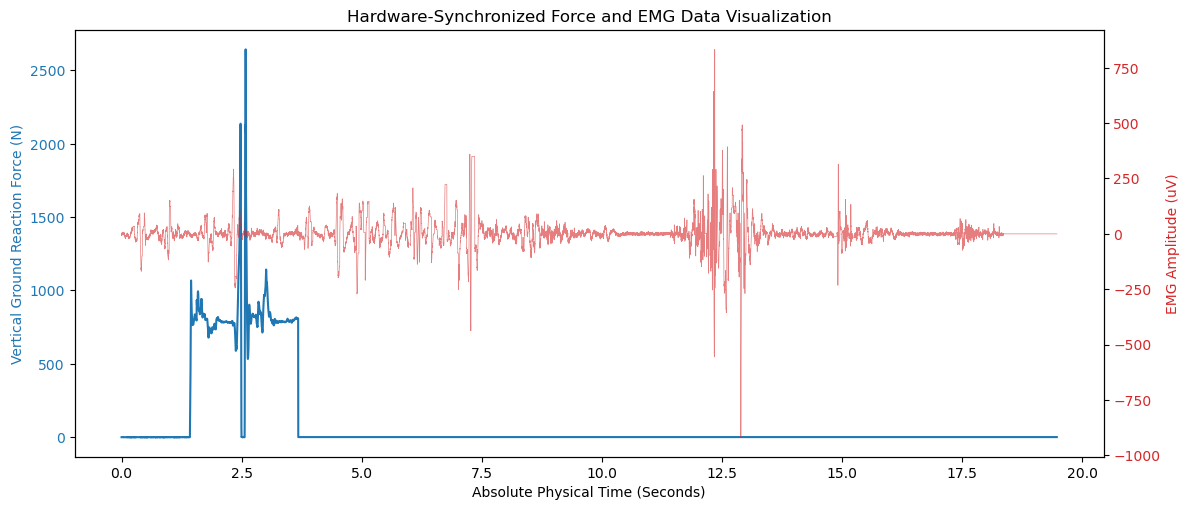

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 提取合并1000Hz的测力台原始垂直力数据
df_f1 = pd.read_csv('TEST0007_f_1.tsv', sep='\t', skiprows=27, header=None, on_bad_lines='skip')
df_f2 = pd.read_csv('TEST0007_f_2.tsv', sep='\t', skiprows=27, header=None, on_bad_lines='skip')
fz_total = pd.to_numeric(df_f1.iloc[:, 2], errors='coerce').fillna(0).values + \
           pd.to_numeric(df_f2.iloc[:, 2], errors='coerce').fillna(0).values

# 生成测力台时间序列 (频率1000Hz -> 每帧0.001秒)
time_fp = np.arange(len(fz_total)) / 1000.0

# 构建带有时间列的新DataFrame并导出保存
df_force_export = pd.DataFrame({'Time_s': time_fp, 'Total_vGRF': fz_total})
df_force_export.to_csv('Force_with_Time.csv', index=False)
print("已成功导出带有时间轴的测力台数据：Force_with_Time.csv")

# 2. 提取2000Hz的左右侧股直肌肌电数据
emg_cols = ['L.Rectus', 'R.Rectus']
df_emg = pd.read_csv('TEST0007_a_1.tsv', sep='\t', skiprows=13, usecols=[2, 3], names=emg_cols, on_bad_lines='skip')

# 生成肌电时间序列 (频率2000Hz -> 每帧0.0005秒)
time_emg = np.arange(len(df_emg)) / 2000.0

# 同样为肌电追加时间列并导出保存
df_emg.insert(0, 'Time_s', time_emg)
df_emg.to_csv('EMG_with_Time.csv', index=False)
print("已成功导出带有时间轴的肌电数据：EMG_with_Time.csv")

# 3. 绘制共享物理绝对时间X轴的双Y轴同步可视化图表
fig, ax1 = plt.subplots(figsize=(12, 5))

# 绘制左轴 (力学数据)
color1 = 'tab:blue'
ax1.set_xlabel('Absolute Physical Time (Seconds)')
ax1.set_ylabel('Vertical Ground Reaction Force (N)', color=color1)
ax1.plot(time_fp, fz_total, color=color1, linewidth=1.5, label='vGRF (1000Hz)')
ax1.tick_params(axis='y', labelcolor=color1)

# 绘制右轴 (以左侧股直肌为例的肌电数据)
ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('EMG Amplitude (uV)', color=color2)  
ax2.plot(time_emg, df_emg['L.Rectus'], color=color2, alpha=0.6, linewidth=0.5, label='Left Rectus Femoris (2000Hz)')
ax2.tick_params(axis='y', labelcolor=color2)

fig.tight_layout()  
plt.title('Hardware-Synchronized Force and EMG Data Visualization')
plt.show()

已成功导出带有时间轴的测力台数据：Force_with_Time.csv
已成功导出带有时间轴的肌电数据：EMG_with_Time.csv


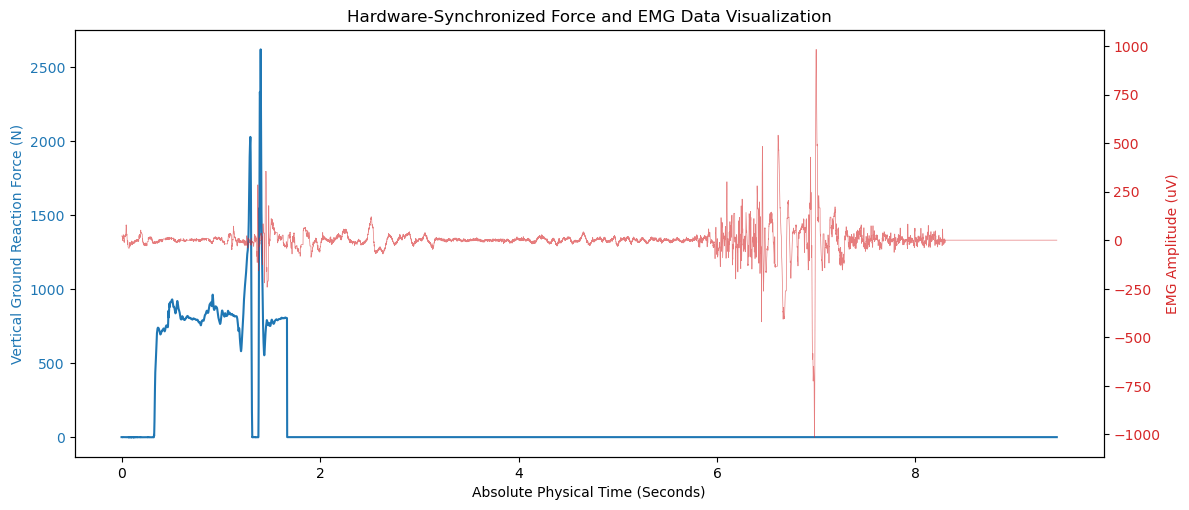

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 提取合并1000Hz的测力台原始垂直力数据
df_f1 = pd.read_csv('TEST0008_f_1.tsv', sep='\t', skiprows=27, header=None, on_bad_lines='skip')
df_f2 = pd.read_csv('TEST0008_f_2.tsv', sep='\t', skiprows=27, header=None, on_bad_lines='skip')
fz_total = pd.to_numeric(df_f1.iloc[:, 2], errors='coerce').fillna(0).values + \
           pd.to_numeric(df_f2.iloc[:, 2], errors='coerce').fillna(0).values

# 生成测力台时间序列 (频率1000Hz -> 每帧0.001秒)
time_fp = np.arange(len(fz_total)) / 1000.0

# 构建带有时间列的新DataFrame并导出保存
df_force_export = pd.DataFrame({'Time_s': time_fp, 'Total_vGRF': fz_total})
df_force_export.to_csv('Force_with_Time.csv', index=False)
print("已成功导出带有时间轴的测力台数据：Force_with_Time.csv")

# 2. 提取2000Hz的左右侧股直肌肌电数据
emg_cols = ['L.Rectus', 'R.Rectus']
df_emg = pd.read_csv('TEST0008_a_1.tsv', sep='\t', skiprows=13, usecols=[2, 3], names=emg_cols, on_bad_lines='skip')

# 生成肌电时间序列 (频率2000Hz -> 每帧0.0005秒)
time_emg = np.arange(len(df_emg)) / 2000.0

# 同样为肌电追加时间列并导出保存
df_emg.insert(0, 'Time_s', time_emg)
df_emg.to_csv('EMG_with_Time.csv', index=False)
print("已成功导出带有时间轴的肌电数据：EMG_with_Time.csv")

# 3. 绘制共享物理绝对时间X轴的双Y轴同步可视化图表
fig, ax1 = plt.subplots(figsize=(12, 5))

# 绘制左轴 (力学数据)
color1 = 'tab:blue'
ax1.set_xlabel('Absolute Physical Time (Seconds)')
ax1.set_ylabel('Vertical Ground Reaction Force (N)', color=color1)
ax1.plot(time_fp, fz_total, color=color1, linewidth=1.5, label='vGRF (1000Hz)')
ax1.tick_params(axis='y', labelcolor=color1)

# 绘制右轴 (以左侧股直肌为例的肌电数据)
ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('EMG Amplitude (uV)', color=color2)  
ax2.plot(time_emg, df_emg['L.Rectus'], color=color2, alpha=0.6, linewidth=0.5, label='Left Rectus Femoris (2000Hz)')
ax2.tick_params(axis='y', labelcolor=color2)

fig.tight_layout()  
plt.title('Hardware-Synchronized Force and EMG Data Visualization')
plt.show()

已成功导出带有时间轴的测力台数据：Force_with_Time.csv
已成功导出带有时间轴的肌电数据：EMG_with_Time.csv


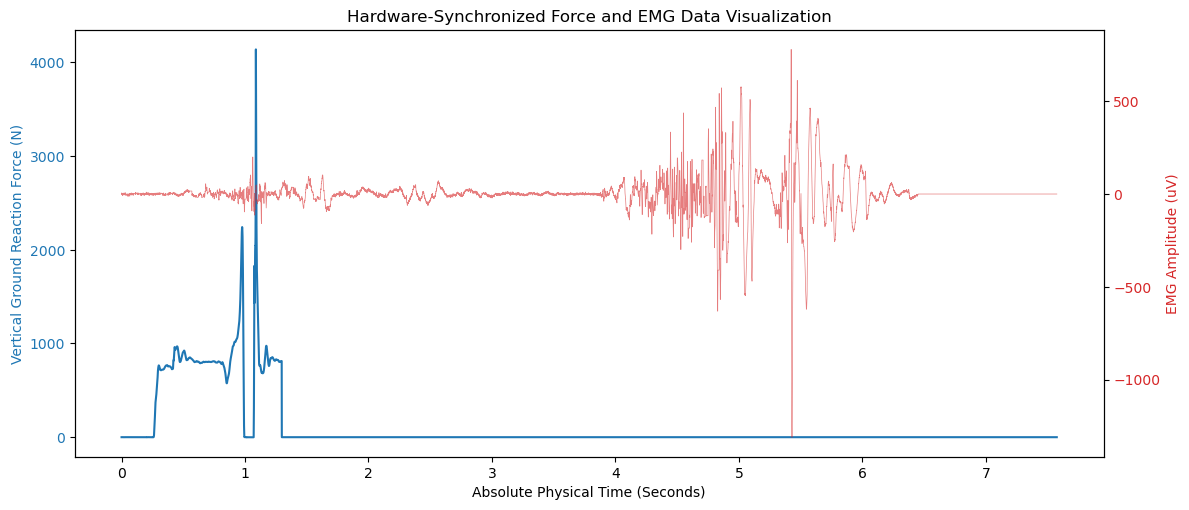

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 提取合并1000Hz的测力台原始垂直力数据
df_f1 = pd.read_csv('TEST0009_f_1.tsv', sep='\t', skiprows=27, header=None, on_bad_lines='skip')
df_f2 = pd.read_csv('TEST0009_f_2.tsv', sep='\t', skiprows=27, header=None, on_bad_lines='skip')
fz_total = pd.to_numeric(df_f1.iloc[:, 2], errors='coerce').fillna(0).values + \
           pd.to_numeric(df_f2.iloc[:, 2], errors='coerce').fillna(0).values

# 生成测力台时间序列 (频率1000Hz -> 每帧0.001秒)
time_fp = np.arange(len(fz_total)) / 1000.0

# 构建带有时间列的新DataFrame并导出保存
df_force_export = pd.DataFrame({'Time_s': time_fp, 'Total_vGRF': fz_total})
df_force_export.to_csv('Force_with_Time.csv', index=False)
print("已成功导出带有时间轴的测力台数据：Force_with_Time.csv")

# 2. 提取2000Hz的左右侧股直肌肌电数据
emg_cols = ['L.Rectus', 'R.Rectus']
df_emg = pd.read_csv('TEST0009_a_1.tsv', sep='\t', skiprows=13, usecols=[2, 3], names=emg_cols, on_bad_lines='skip')

# 生成肌电时间序列 (频率2000Hz -> 每帧0.0005秒)
time_emg = np.arange(len(df_emg)) / 2000.0

# 同样为肌电追加时间列并导出保存
df_emg.insert(0, 'Time_s', time_emg)
df_emg.to_csv('EMG_with_Time.csv', index=False)
print("已成功导出带有时间轴的肌电数据：EMG_with_Time.csv")

# 3. 绘制共享物理绝对时间X轴的双Y轴同步可视化图表
fig, ax1 = plt.subplots(figsize=(12, 5))

# 绘制左轴 (力学数据)
color1 = 'tab:blue'
ax1.set_xlabel('Absolute Physical Time (Seconds)')
ax1.set_ylabel('Vertical Ground Reaction Force (N)', color=color1)
ax1.plot(time_fp, fz_total, color=color1, linewidth=1.5, label='vGRF (1000Hz)')
ax1.tick_params(axis='y', labelcolor=color1)

# 绘制右轴 (以左侧股直肌为例的肌电数据)
ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('EMG Amplitude (uV)', color=color2)  
ax2.plot(time_emg, df_emg['L.Rectus'], color=color2, alpha=0.6, linewidth=0.5, label='Left Rectus Femoris (2000Hz)')
ax2.tick_params(axis='y', labelcolor=color2)

fig.tight_layout()  
plt.title('Hardware-Synchronized Force and EMG Data Visualization')
plt.show()

已成功导出带有时间轴的测力台数据：Force_with_Time.csv
已成功导出带有时间轴的肌电数据：EMG_with_Time.csv


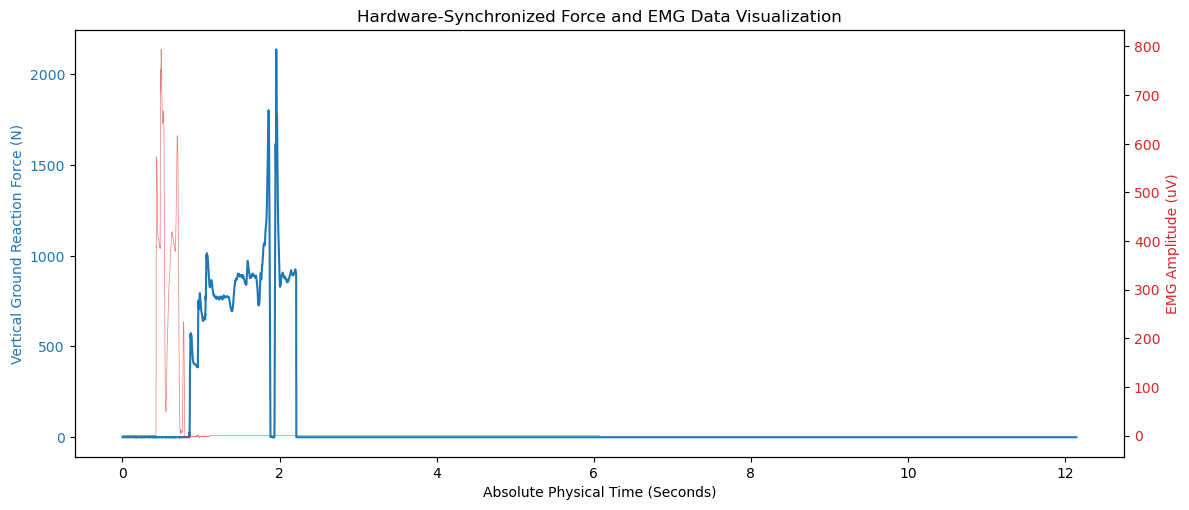

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 提取合并1000Hz的测力台原始垂直力数据
df_f1 = pd.read_csv('TEST0010_f_1.tsv', sep='\t', skiprows=27, header=None, on_bad_lines='skip')
df_f2 = pd.read_csv('TEST0010_f_2.tsv', sep='\t', skiprows=27, header=None, on_bad_lines='skip')
fz_total = pd.to_numeric(df_f1.iloc[:, 2], errors='coerce').fillna(0).values + \
           pd.to_numeric(df_f2.iloc[:, 2], errors='coerce').fillna(0).values

# 生成测力台时间序列 (频率1000Hz -> 每帧0.001秒)
time_fp = np.arange(len(fz_total)) / 1000.0

# 构建带有时间列的新DataFrame并导出保存
df_force_export = pd.DataFrame({'Time_s': time_fp, 'Total_vGRF': fz_total})
df_force_export.to_csv('Force_with_Time.csv', index=False)
print("已成功导出带有时间轴的测力台数据：Force_with_Time.csv")

# 2. 提取2000Hz的左右侧股直肌肌电数据
emg_cols = ['L.Rectus', 'R.Rectus']
df_emg = pd.read_csv('TEST0010_a_1.tsv', sep='\t', skiprows=13, usecols=[2, 3], names=emg_cols, on_bad_lines='skip')

# 生成肌电时间序列 (频率2000Hz -> 每帧0.0005秒)
time_emg = np.arange(len(df_emg)) / 2000.0

# 同样为肌电追加时间列并导出保存
df_emg.insert(0, 'Time_s', time_emg)
df_emg.to_csv('EMG_with_Time.csv', index=False)
print("已成功导出带有时间轴的肌电数据：EMG_with_Time.csv")

# 3. 绘制共享物理绝对时间X轴的双Y轴同步可视化图表
fig, ax1 = plt.subplots(figsize=(12, 5))

# 绘制左轴 (力学数据)
color1 = 'tab:blue'
ax1.set_xlabel('Absolute Physical Time (Seconds)')
ax1.set_ylabel('Vertical Ground Reaction Force (N)', color=color1)
ax1.plot(time_fp, fz_total, color=color1, linewidth=1.5, label='vGRF (1000Hz)')
ax1.tick_params(axis='y', labelcolor=color1)

# 绘制右轴 (以左侧股直肌为例的肌电数据)
ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('EMG Amplitude (uV)', color=color2)  
ax2.plot(time_emg, df_emg['L.Rectus'], color=color2, alpha=0.6, linewidth=0.5, label='Left Rectus Femoris (2000Hz)')
ax2.tick_params(axis='y', labelcolor=color2)

fig.tight_layout()  
plt.title('Hardware-Synchronized Force and EMG Data Visualization')
plt.show()

已成功导出带有时间轴的测力台数据：Force_with_Time.csv
已成功导出带有时间轴的肌电数据：EMG_with_Time.csv


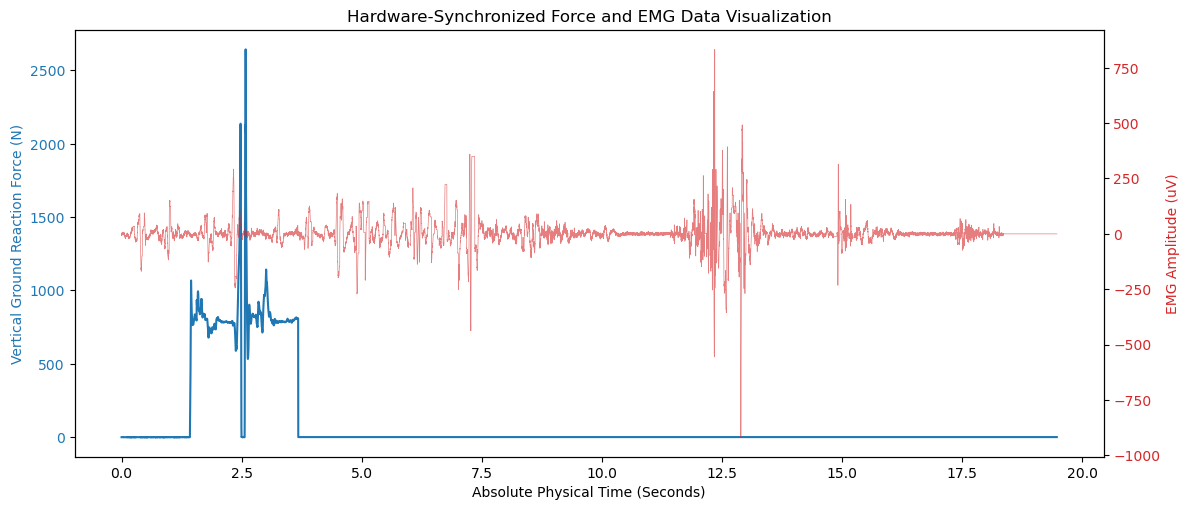

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 提取合并1000Hz的测力台原始垂直力数据
df_f1 = pd.read_csv('TEST0007_f_1.tsv', sep='\t', skiprows=27, header=None, on_bad_lines='skip')
df_f2 = pd.read_csv('TEST0007_f_2.tsv', sep='\t', skiprows=27, header=None, on_bad_lines='skip')
fz_total = pd.to_numeric(df_f1.iloc[:, 2], errors='coerce').fillna(0).values + \
           pd.to_numeric(df_f2.iloc[:, 2], errors='coerce').fillna(0).values

# 生成测力台时间序列 (频率1000Hz -> 每帧0.001秒)
time_fp = np.arange(len(fz_total)) / 1000.0

# 构建带有时间列的新DataFrame并导出保存
df_force_export = pd.DataFrame({'Time_s': time_fp, 'Total_vGRF': fz_total})
df_force_export.to_csv('Force_with_Time.csv', index=False)
print("已成功导出带有时间轴的测力台数据：Force_with_Time.csv")

# 2. 提取2000Hz的左右侧股直肌肌电数据
emg_cols = ['L.Rectus', 'R.Rectus']
df_emg = pd.read_csv('TEST0007_a_1.tsv', sep='\t', skiprows=13, usecols=[2, 3], names=emg_cols, on_bad_lines='skip')

# 生成肌电时间序列 (频率2000Hz -> 每帧0.0005秒)
time_emg = np.arange(len(df_emg)) / 2000.0

# 同样为肌电追加时间列并导出保存
df_emg.insert(0, 'Time_s', time_emg)
df_emg.to_csv('EMG_with_Time.csv', index=False)
print("已成功导出带有时间轴的肌电数据：EMG_with_Time.csv")

# 3. 绘制共享物理绝对时间X轴的双Y轴同步可视化图表
fig, ax1 = plt.subplots(figsize=(12, 5))

# 绘制左轴 (力学数据)
color1 = 'tab:blue'
ax1.set_xlabel('Absolute Physical Time (Seconds)')
ax1.set_ylabel('Vertical Ground Reaction Force (N)', color=color1)
ax1.plot(time_fp, fz_total, color=color1, linewidth=1.5, label='vGRF (1000Hz)')
ax1.tick_params(axis='y', labelcolor=color1)

# 绘制右轴 (以左侧股直肌为例的肌电数据)
ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('EMG Amplitude (uV)', color=color2)  
ax2.plot(time_emg, df_emg['L.Rectus'], color=color2, alpha=0.6, linewidth=0.5, label='Left Rectus Femoris (2000Hz)')
ax2.tick_params(axis='y', labelcolor=color2)

fig.tight_layout()  
plt.title('Hardware-Synchronized Force and EMG Data Visualization')
plt.show()